# Using Indicators with MplChart (pandas only)

Built-in technical indicators available in `mplchart.indicators`.
Indicator can be composed used with primitives to customized randering.


In [1]:
from mplchart.chart import Chart
from mplchart.samples import sample_prices
from mplchart.primitives import Candlesticks, Volume, LinePlot
from mplchart.indicators import (
    SMA, EMA, DEMA, TEMA, HMA,
    ROC, RSI,
    MACD, MACDV, PPO,
    BOP, DMI,
    BBANDS, BBP, BBW, KELTNER, DONCHIAN,
    STOCH,
)

prices = sample_prices()

## Moving Averages

`SMA` (Simple), `EMA` (Exponential), `DEMA` (Double EMA), `TEMA` (Triple EMA), `HMA` (Hull MA).

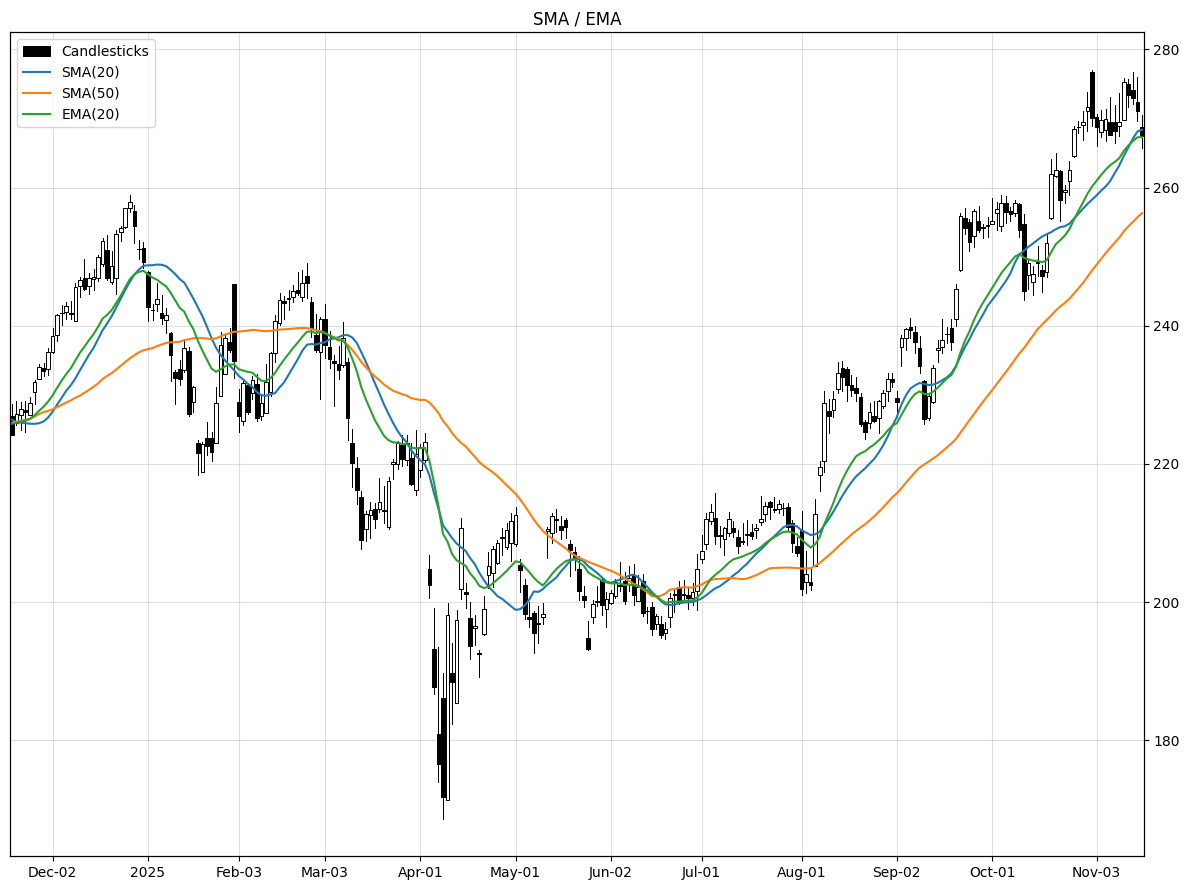

In [2]:
# SMA and EMA overlays
Chart(prices, title="SMA / EMA", max_bars=250).plot(
    Candlesticks(),
    SMA(20),
    SMA(50),
    EMA(20),
).show()

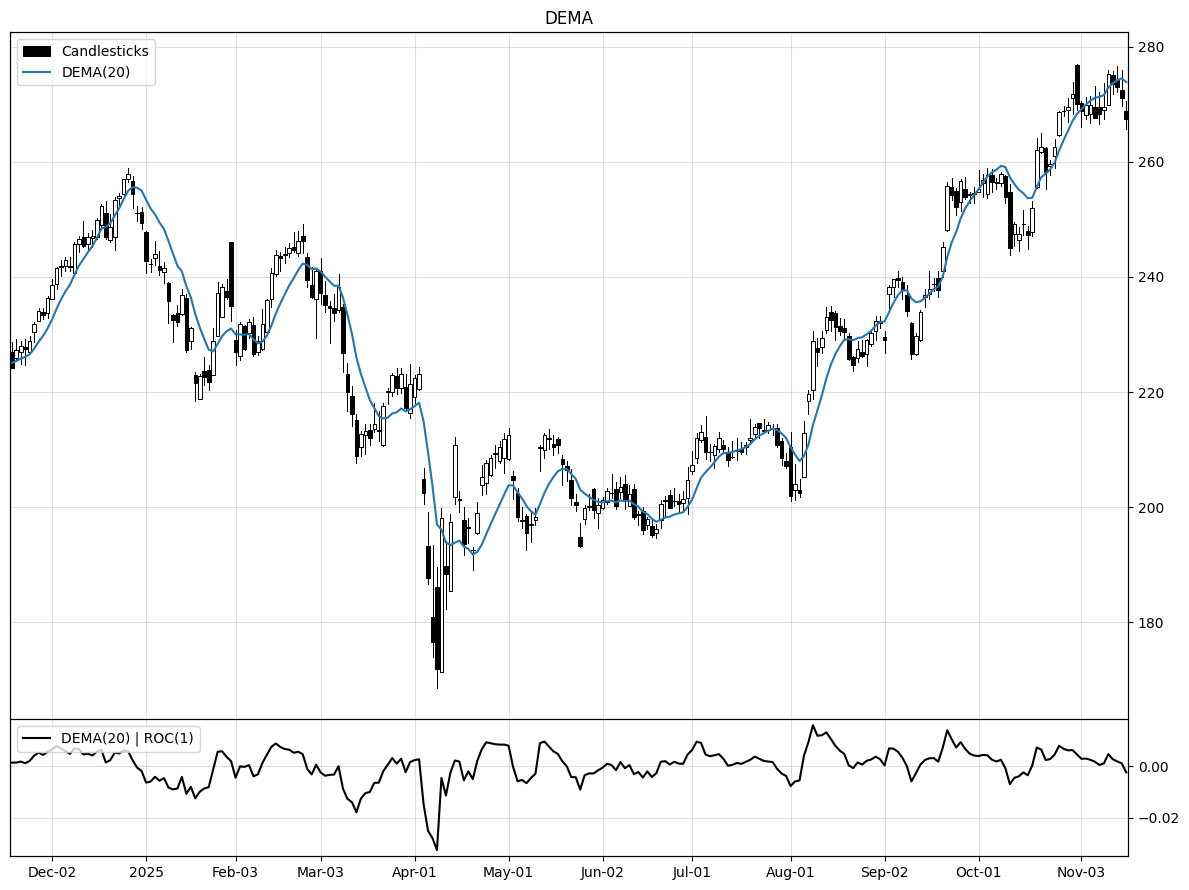

In [3]:
# DEMA with rate-of-change
Chart(prices, title="DEMA", max_bars=250).plot(
    Candlesticks(), DEMA(20)
).pane("below").plot(
    DEMA(20) | ROC(1)
).show()

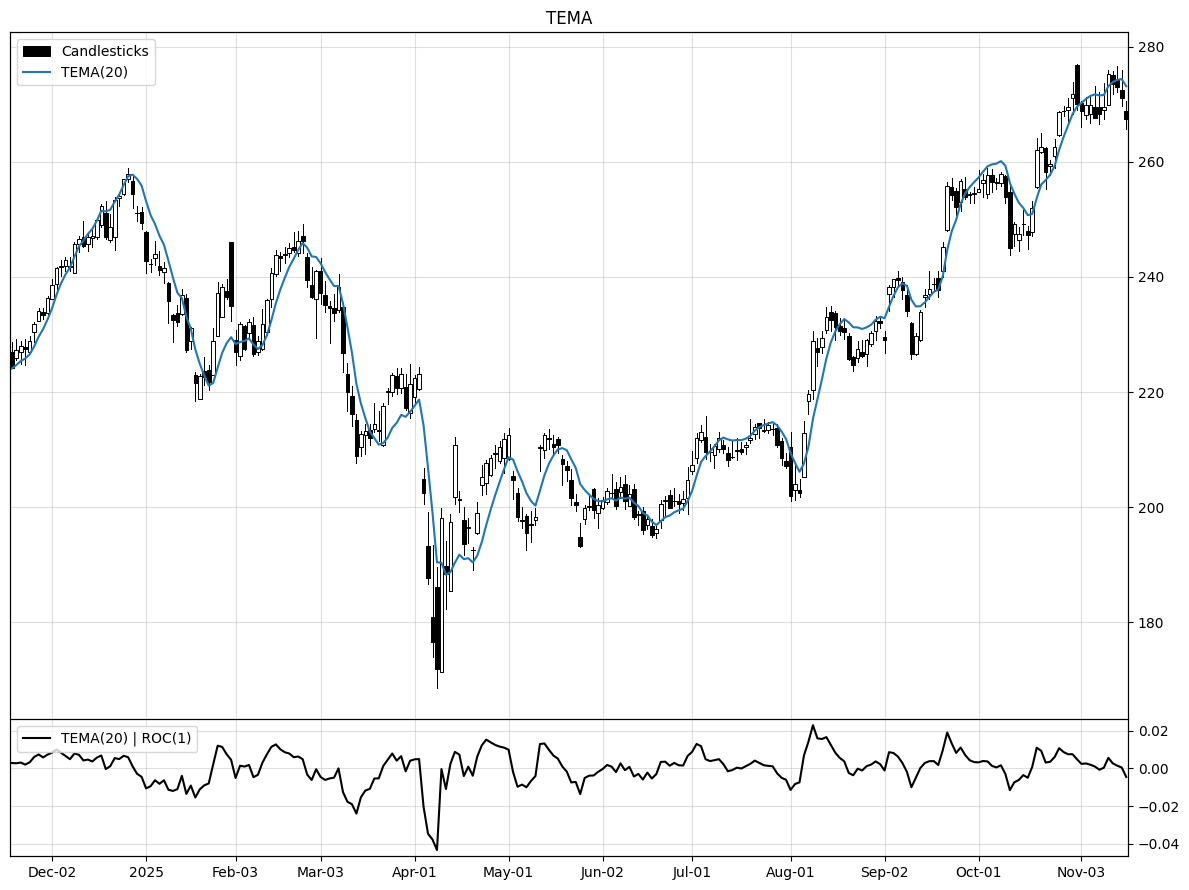

In [4]:
# TEMA with rate-of-change
Chart(prices, title="TEMA", max_bars=250).plot(
    Candlesticks(), TEMA(20)
).pane("below").plot(
    TEMA(20) | ROC(1)
).show()

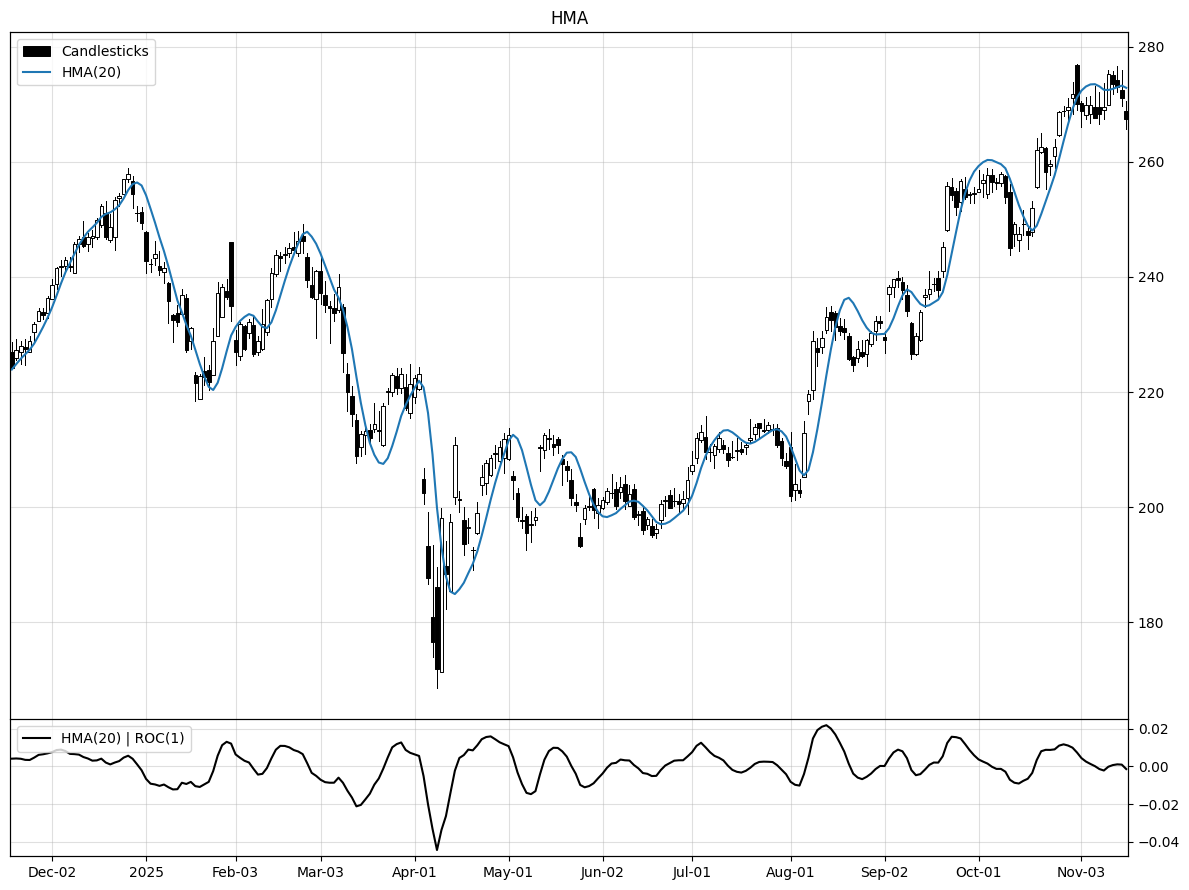

In [5]:
# HMA with rate-of-change
Chart(prices, title="HMA", max_bars=250).plot(
    Candlesticks(), HMA(20)
).pane("below").plot(
    HMA(20) | ROC(1)
).show()

## Bollinger Bands

`BBANDS` overlays the bands on price. `BBP` (Bollinger %B) and `BBW` (Bandwidth) are companion oscillators.

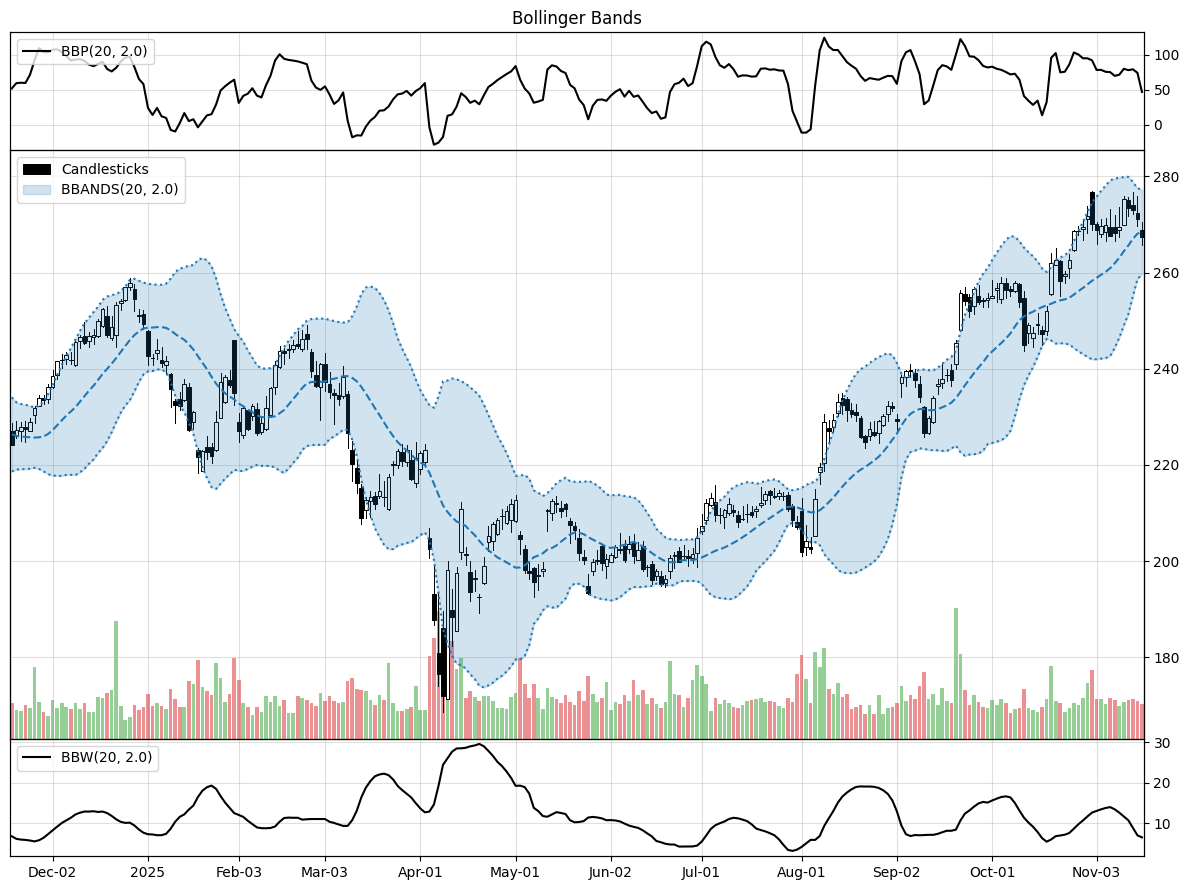

In [6]:
Chart(prices, title="Bollinger Bands", max_bars=250).plot(
    Candlesticks(), Volume(), BBANDS(),
).pane("above").plot(
    BBP()
).pane("below").plot(
    BBW()
).show()

## MACD

`MACD` (Moving Average Convergence Divergence) and `MACDV` (volume-weighted variant).

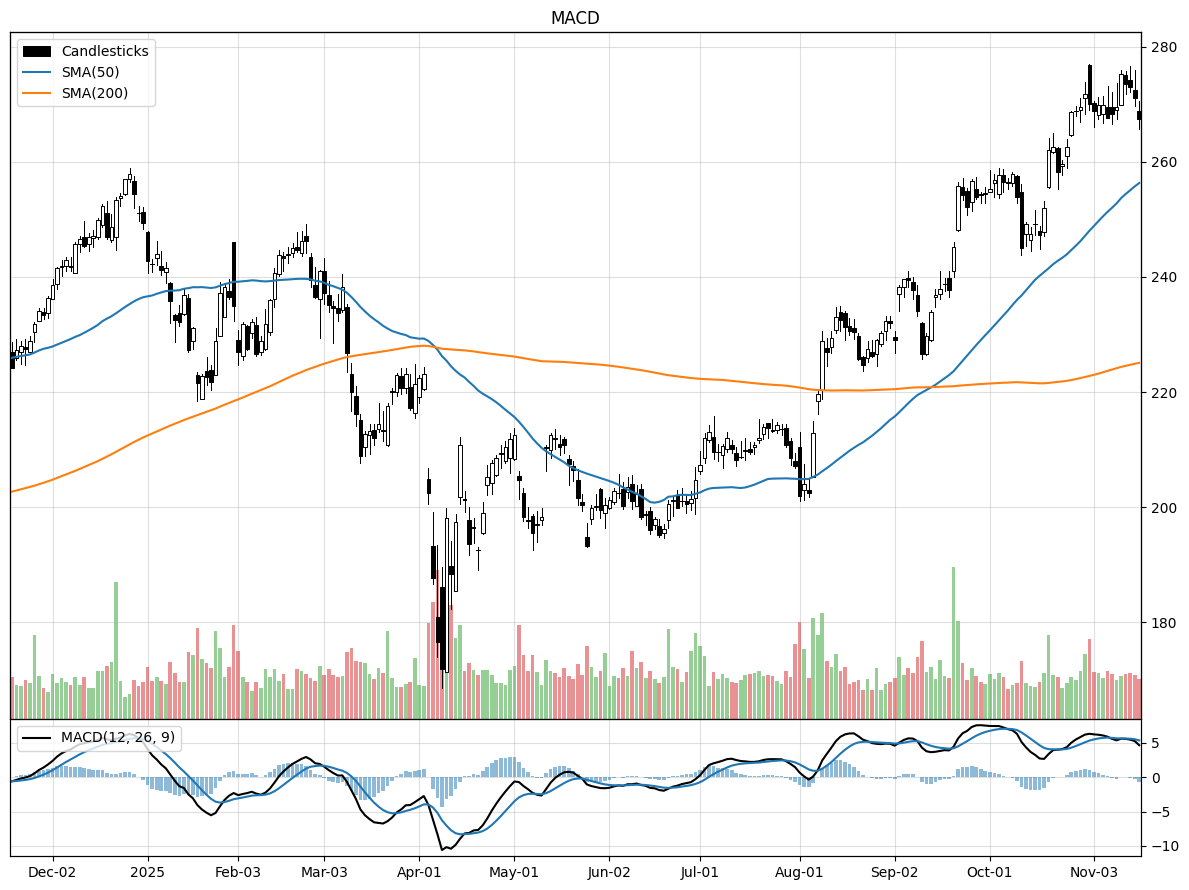

In [7]:
Chart(prices, title="MACD", max_bars=250).plot(
    Candlesticks(),
    SMA(50),
    SMA(200),
    Volume(),
).pane("below").plot(
    MACD()
).show()

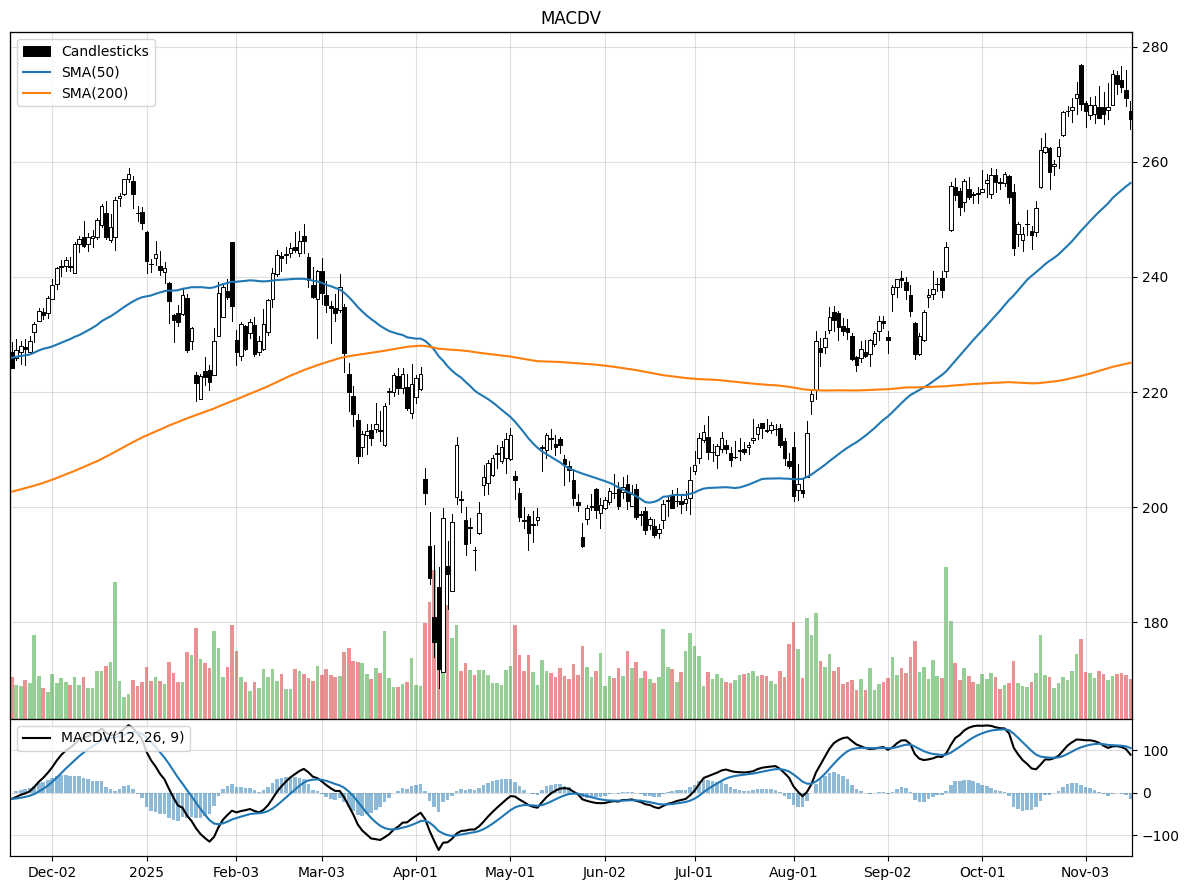

In [8]:
Chart(prices, title="MACDV", max_bars=250).plot(
    Candlesticks(),
    SMA(50),
    SMA(200),
    Volume(),
).pane("below").plot(
    MACDV(),
).show()

## RSI

Relative Strength Index oscillator.

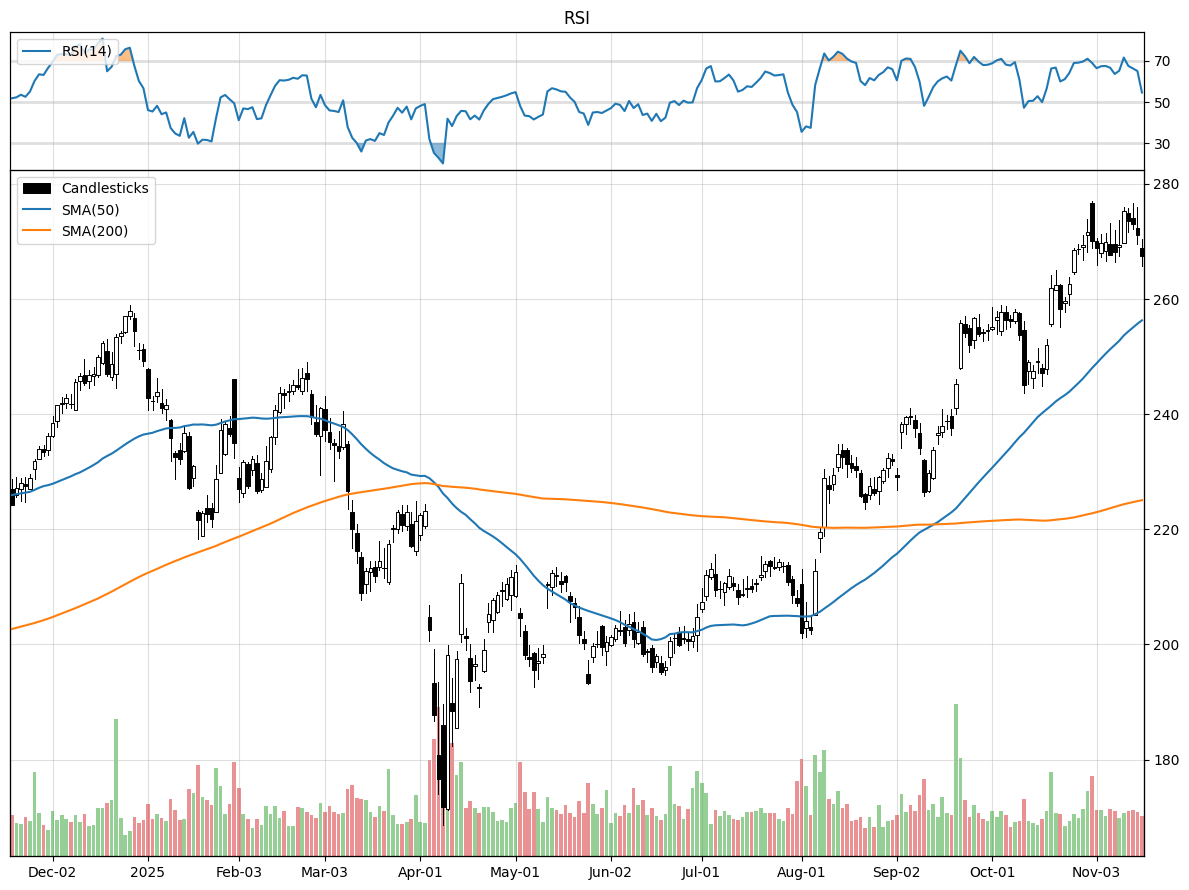

In [9]:
Chart(prices, title="RSI", max_bars=250).plot(
    Candlesticks(),
    SMA(50),
    SMA(200),
    Volume(),
).pane("above", yticks=(30, 50, 70)).plot(
    LinePlot(RSI(), overbought=70, oversold=30)
).show()

## Stochastic Oscillator

`STOCH` returns %K and %D lines.

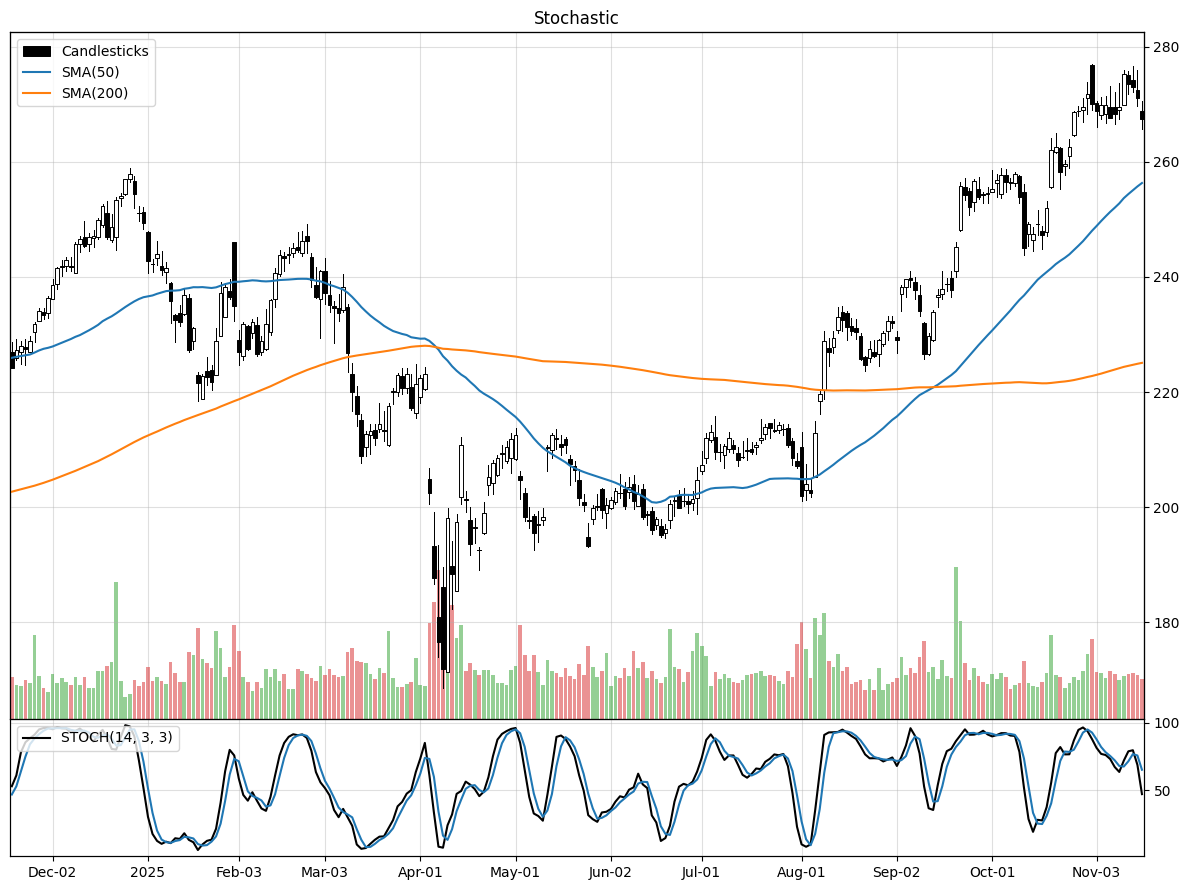

In [10]:
Chart(prices, title="Stochastic", max_bars=250).plot(
    Candlesticks(),
    SMA(50),
    SMA(200),
    Volume(),
).pane("below").plot(
    STOCH()
).show()

## DMI

Directional Movement Index: ADX with +DI and -DI.

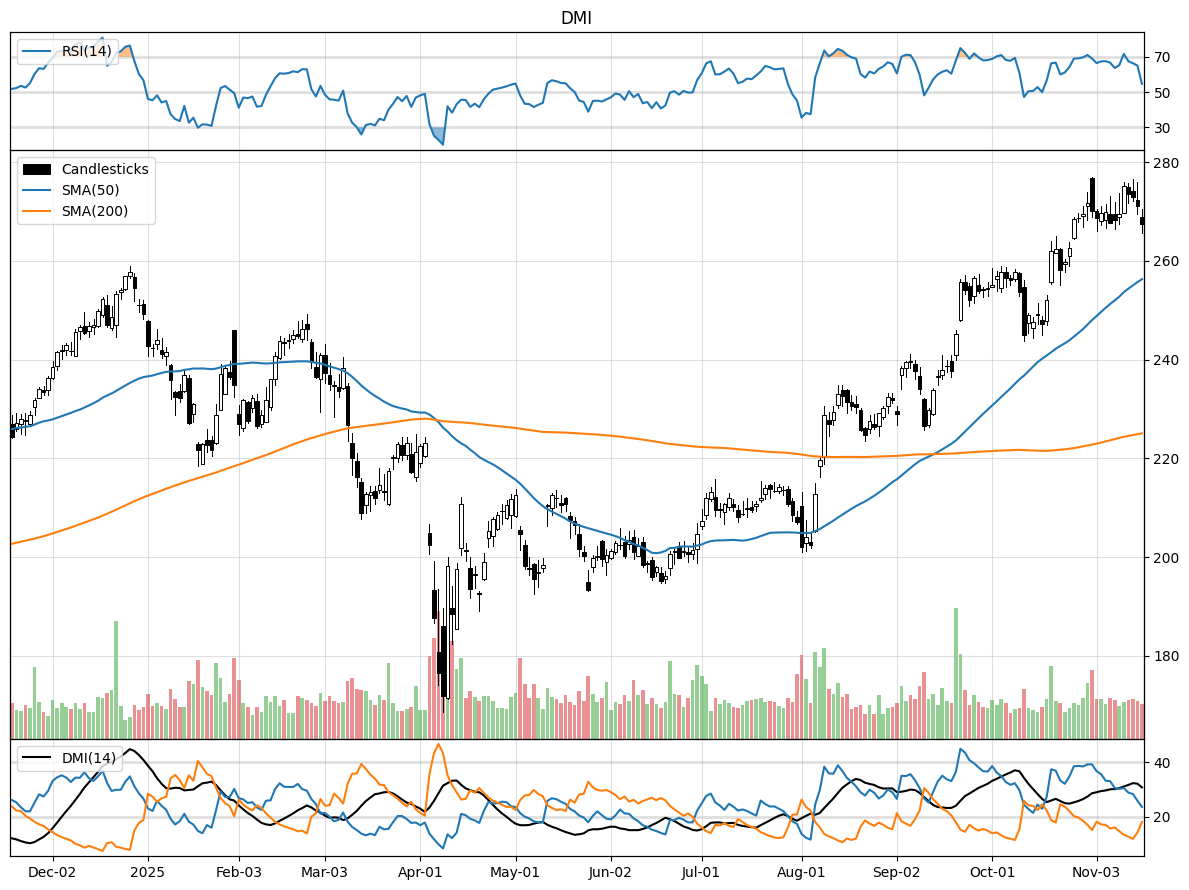

In [11]:
Chart(prices, title="DMI", max_bars=250).plot(
    Candlesticks(),
    SMA(50),
    SMA(200),
    Volume(),
).pane("above", yticks=(30, 50, 70)).plot(
    LinePlot(RSI(), overbought=70, oversold=30)
).pane("below", yticks=(20, 40)).plot(
    DMI()
).show()

## PPO

Percentage Price Oscillator — similar to MACD but expressed as a percentage.

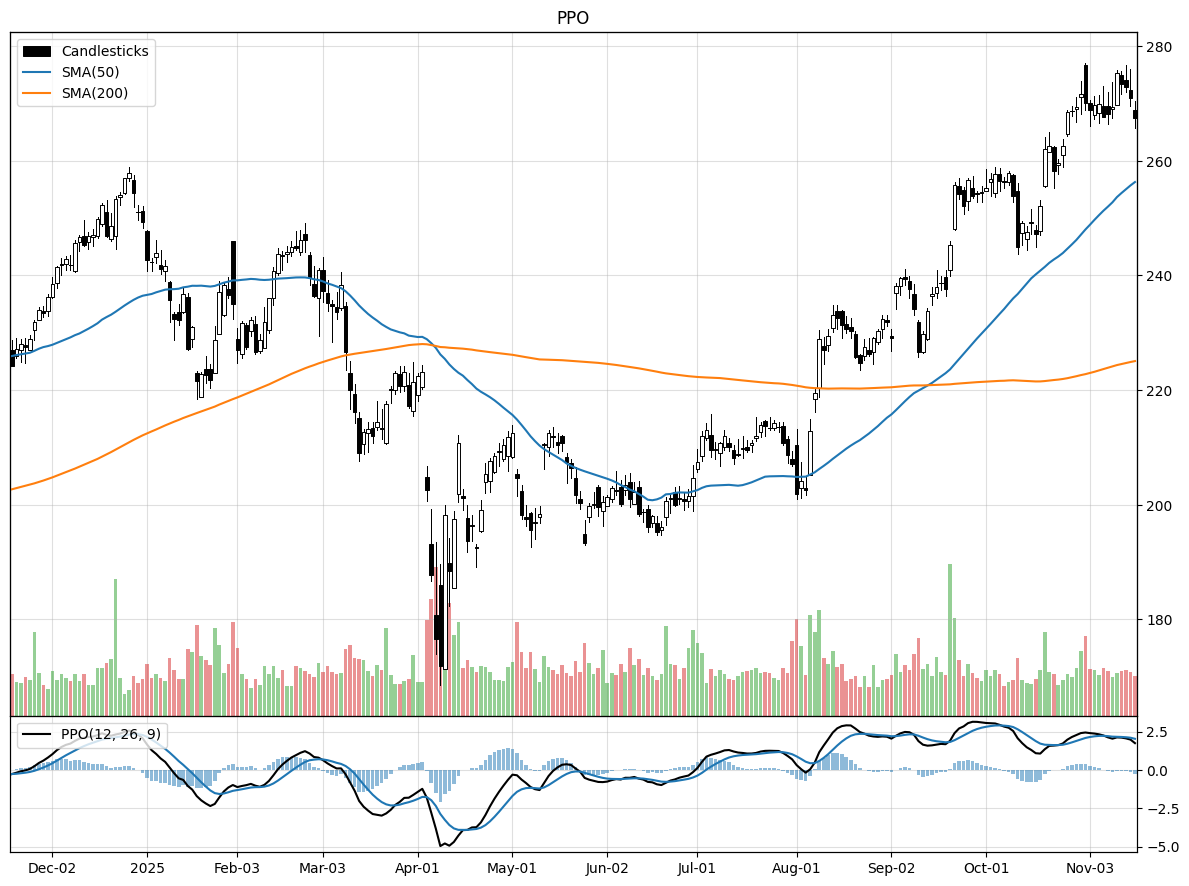

In [12]:
Chart(prices, title="PPO", max_bars=250).plot(
    Candlesticks(),
    SMA(50),
    SMA(200),
    Volume(),
).pane("below").plot(
    PPO()
).show()

## Balance of Power

`BOP` measures the balance between buying and selling pressure.

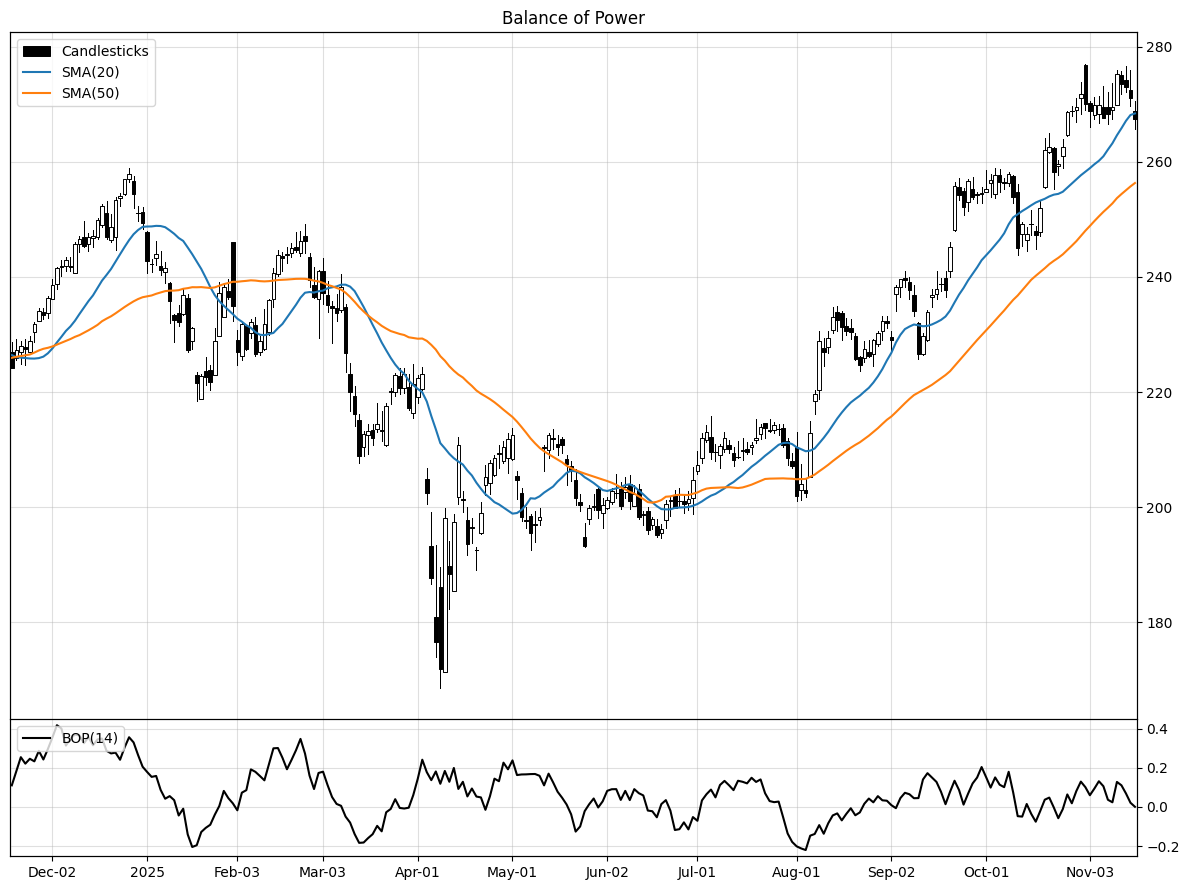

In [13]:
Chart(prices, title="Balance of Power", max_bars=250).plot(
    Candlesticks(), SMA(20), SMA(50)
).pane("below").plot(
    BOP(14)
).show()

## Donchian Channel

Highest high / lowest low over a lookback period.

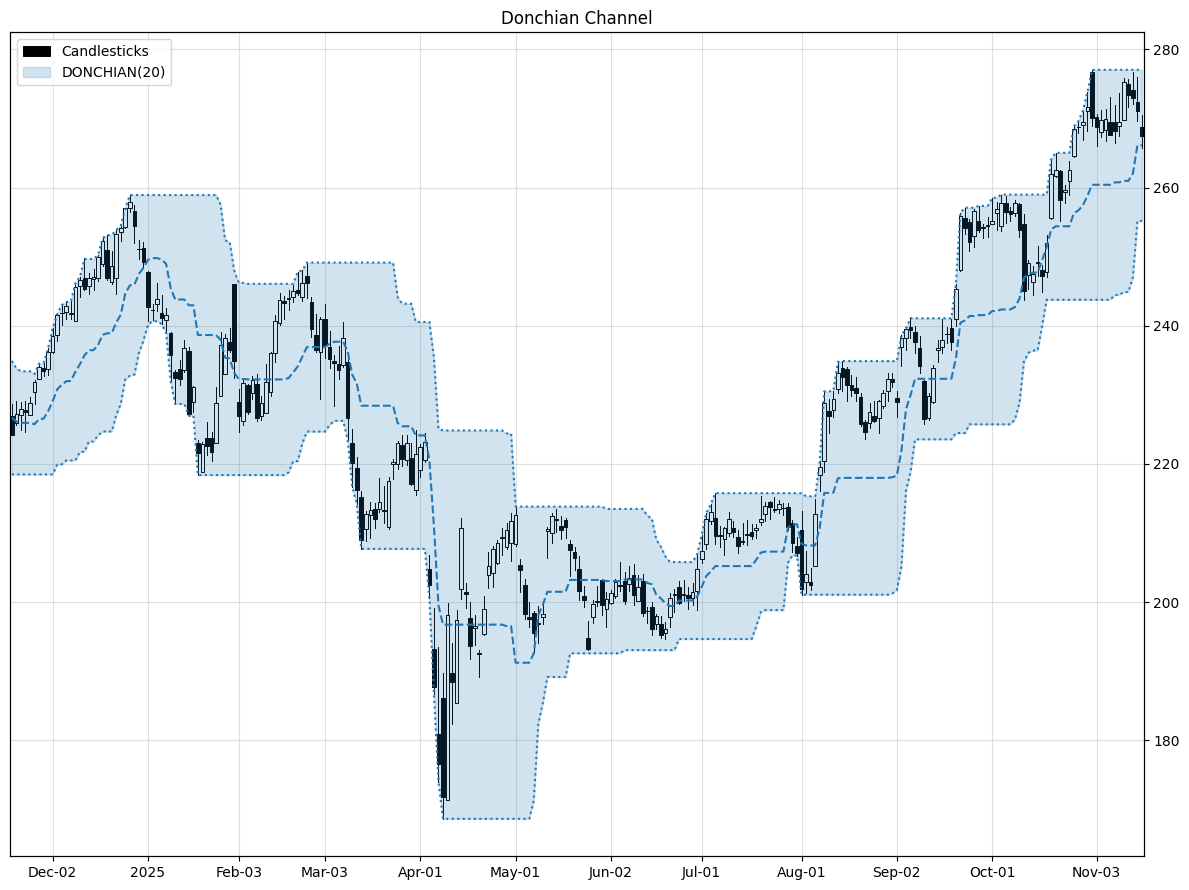

In [14]:
Chart(prices, title="Donchian Channel", max_bars=250).plot(
    Candlesticks(), DONCHIAN()
).show()

## Keltner Channel

EMA-based channel using ATR for band width.

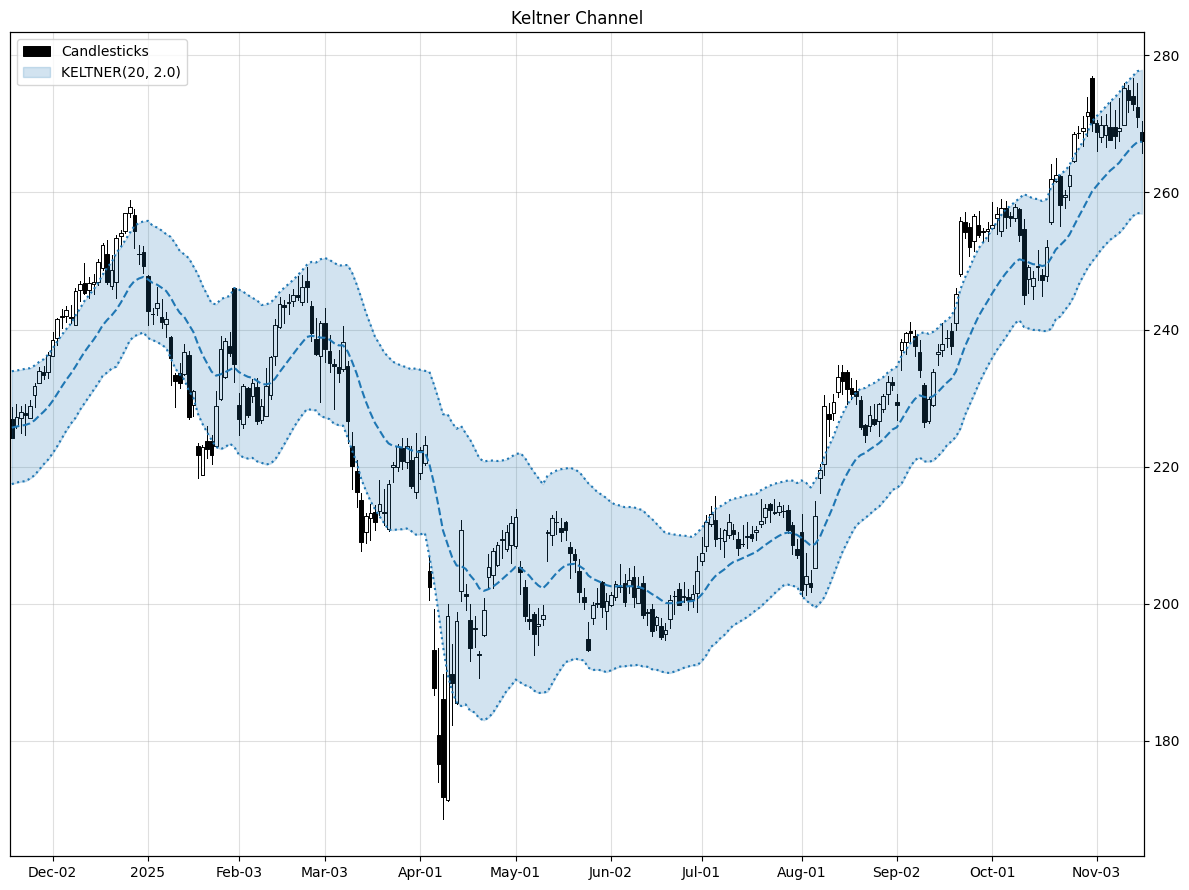

In [15]:
Chart(prices, title="Keltner Channel", max_bars=250).plot(
    Candlesticks(), KELTNER()
).show()